Histogram:


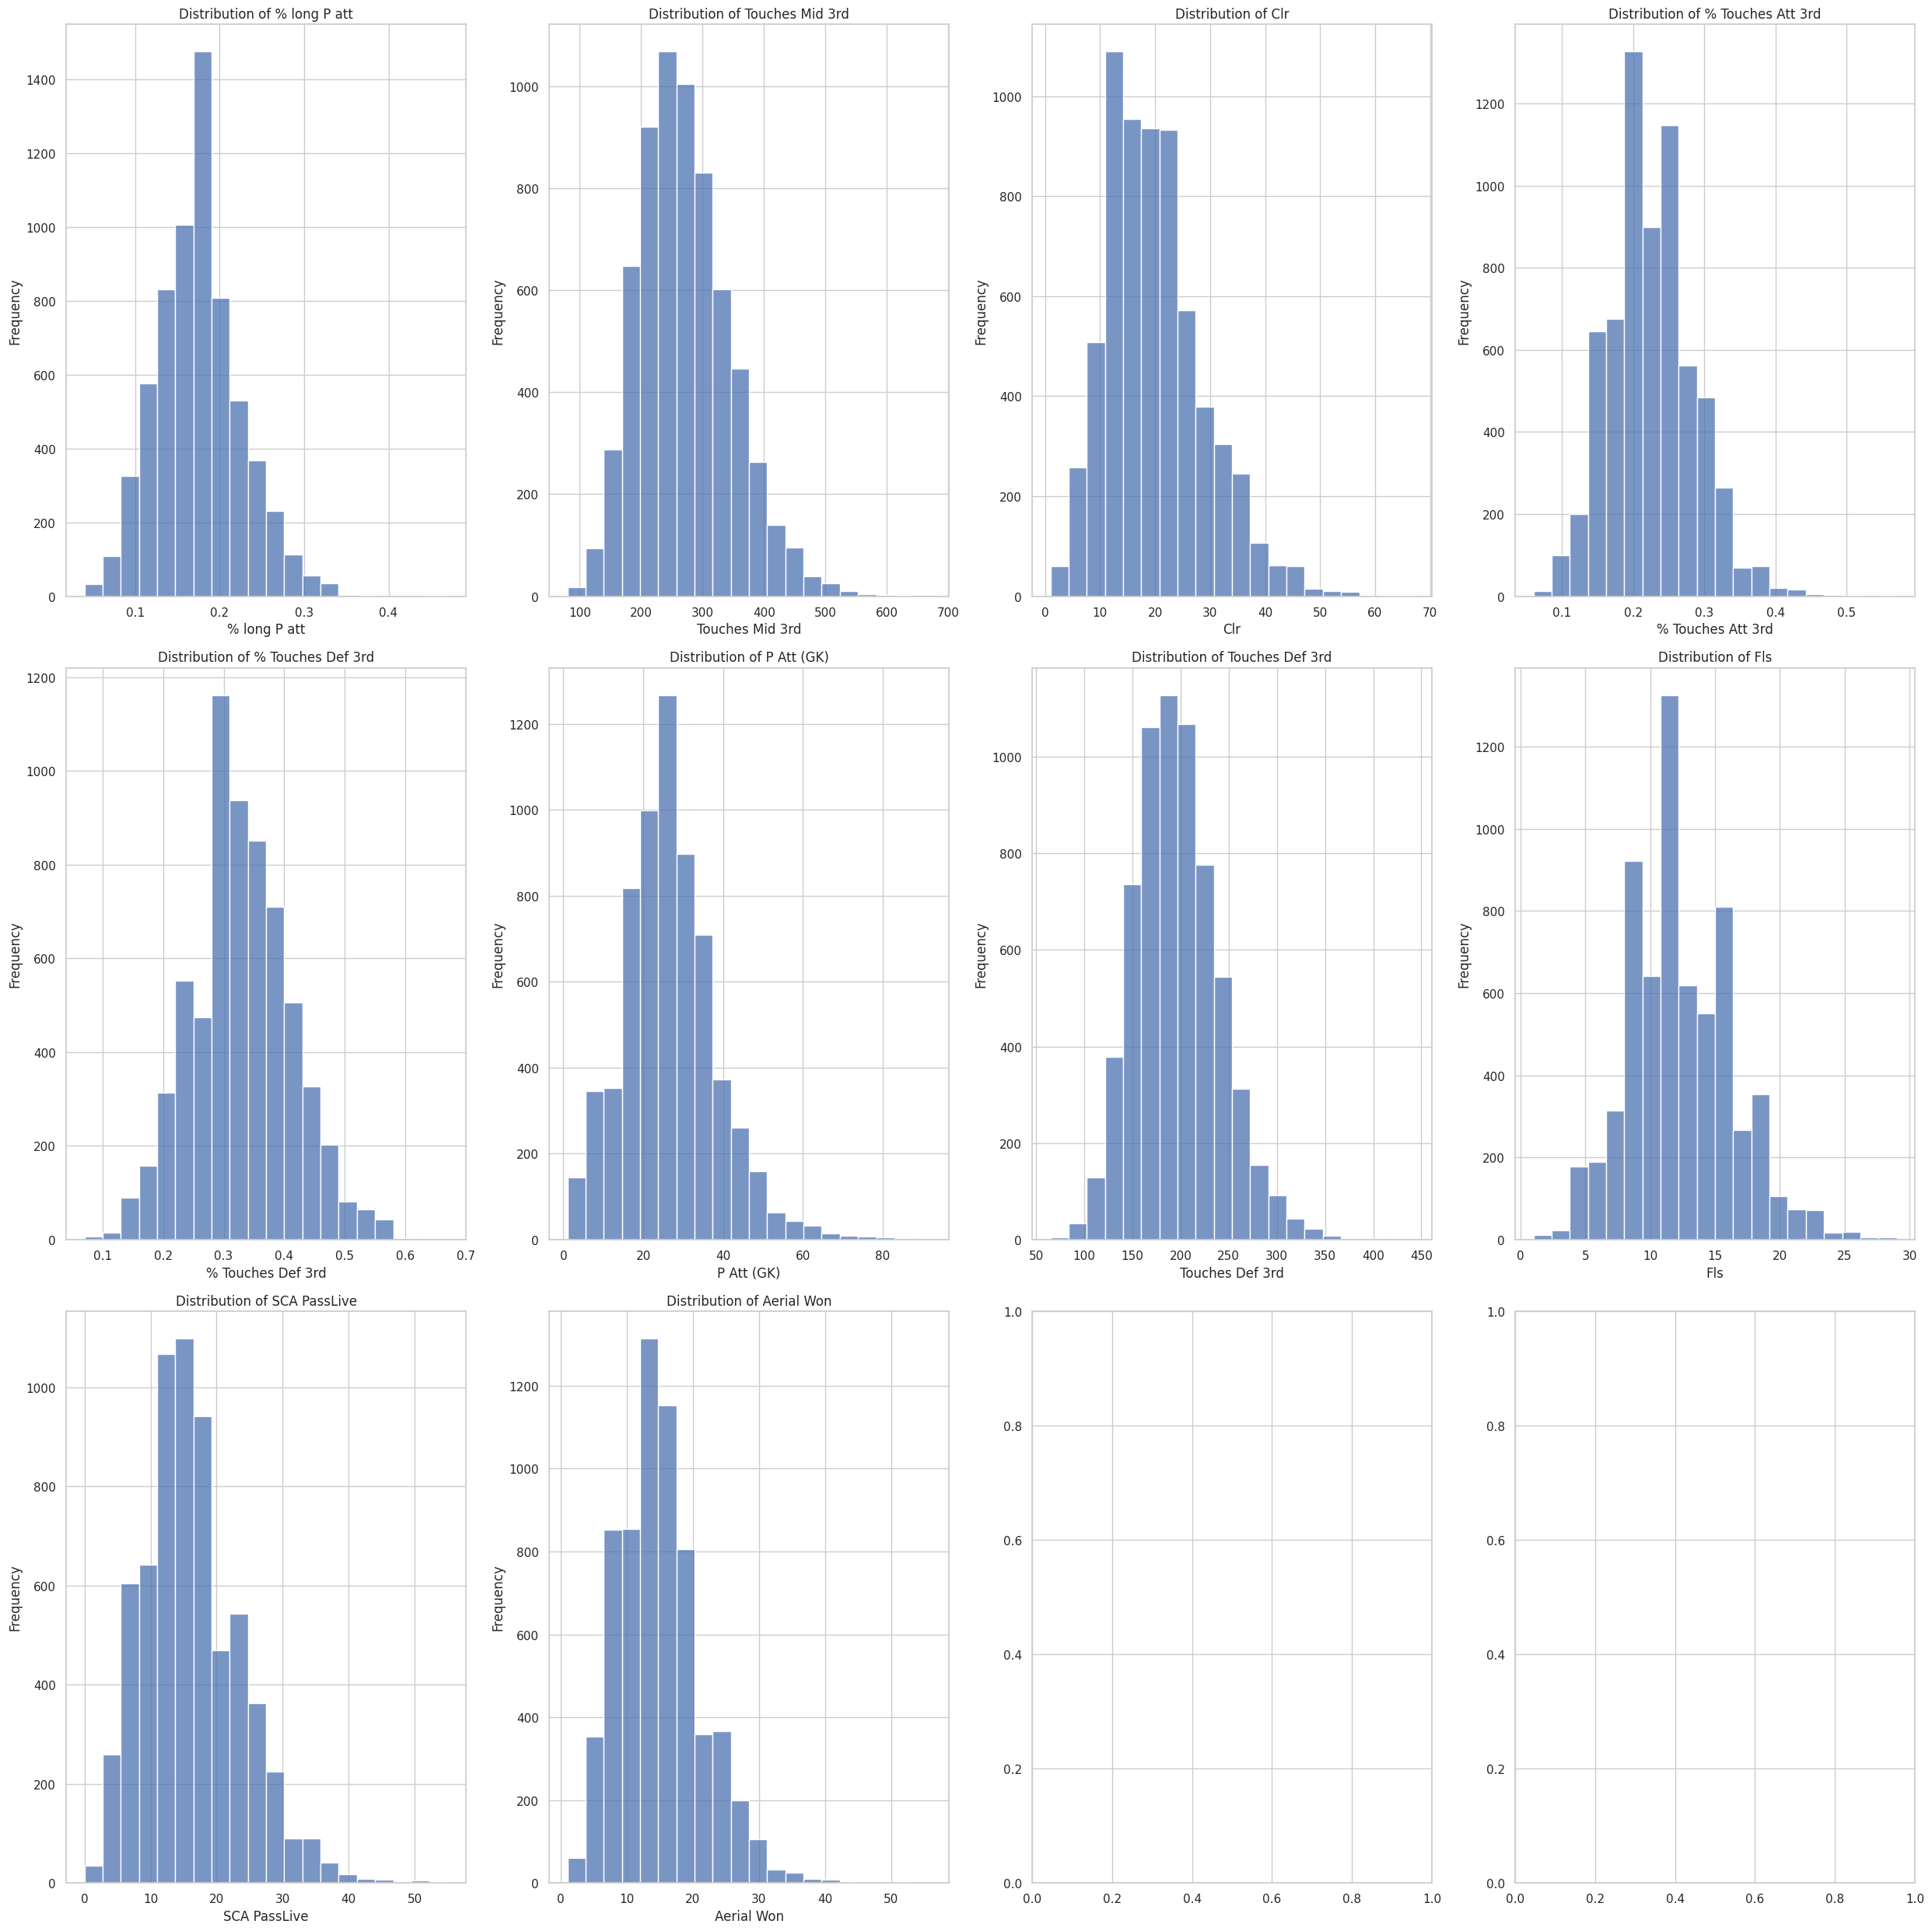

Correlation Heatmap:
Boxplot:


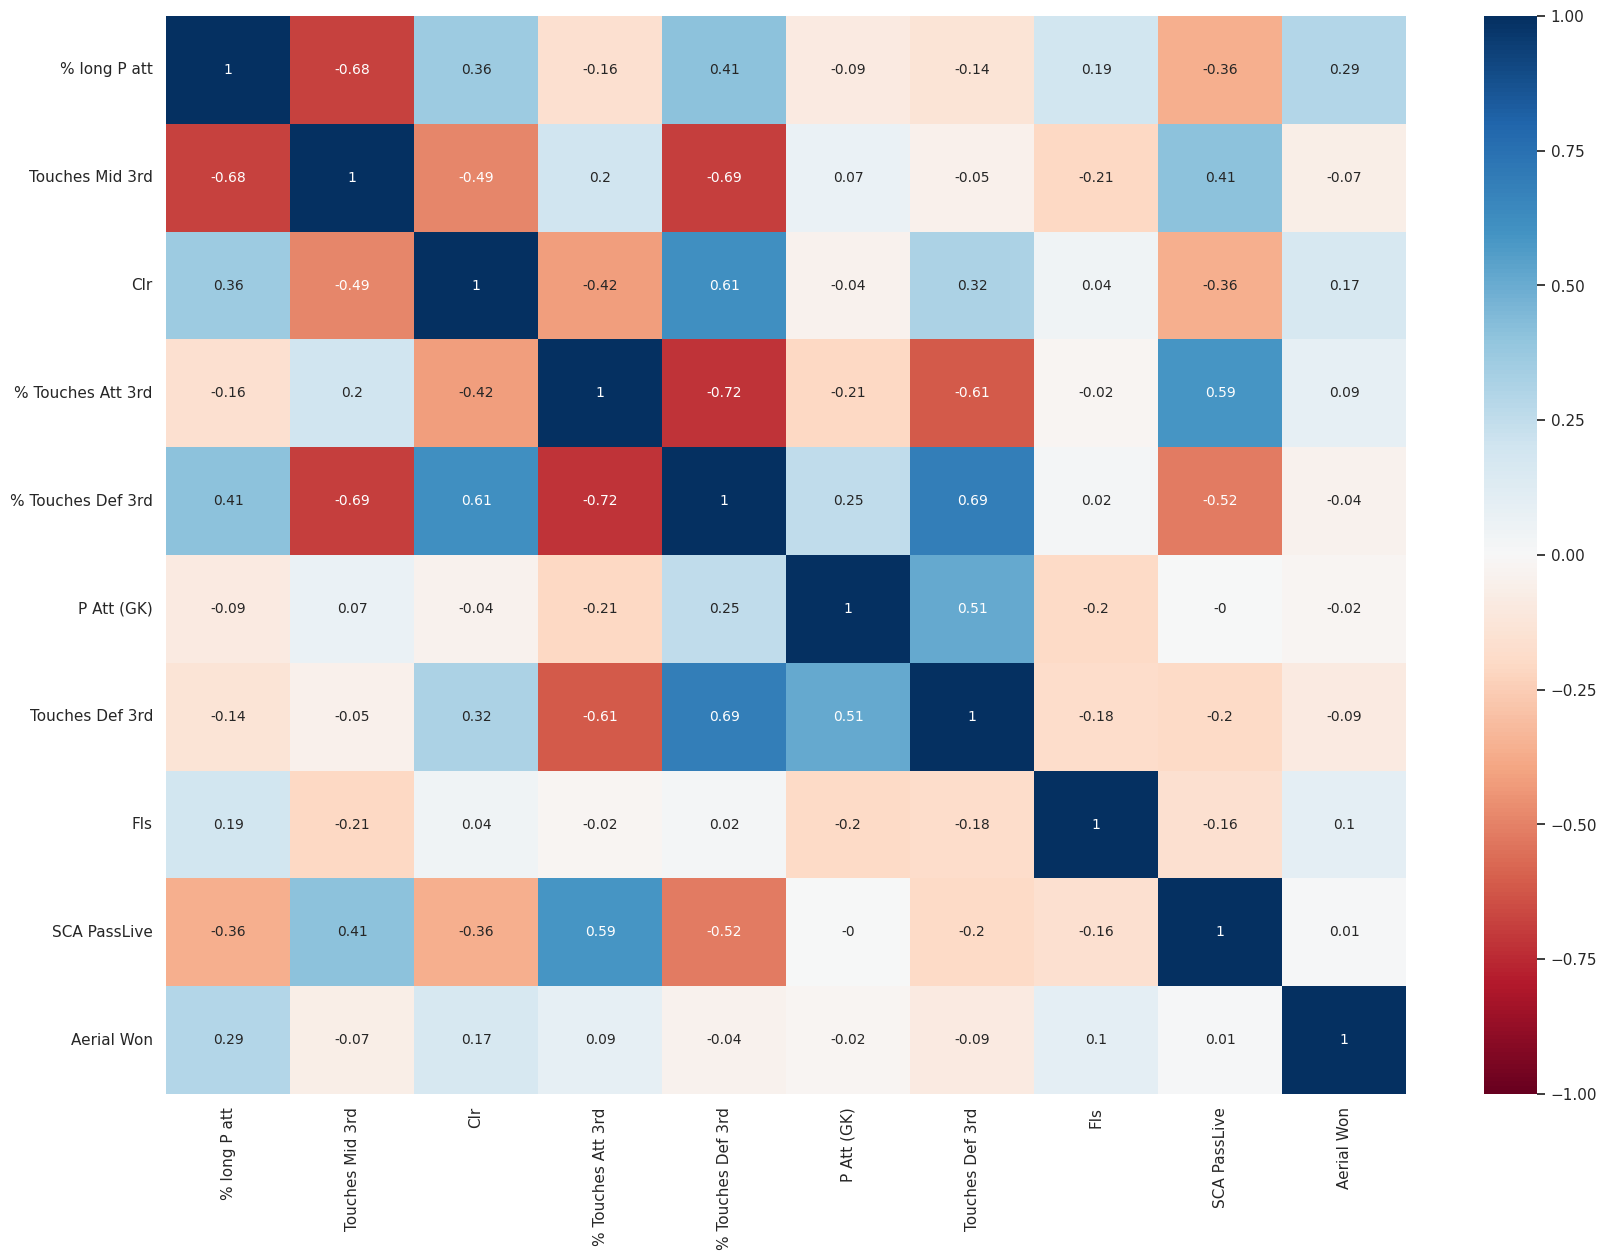

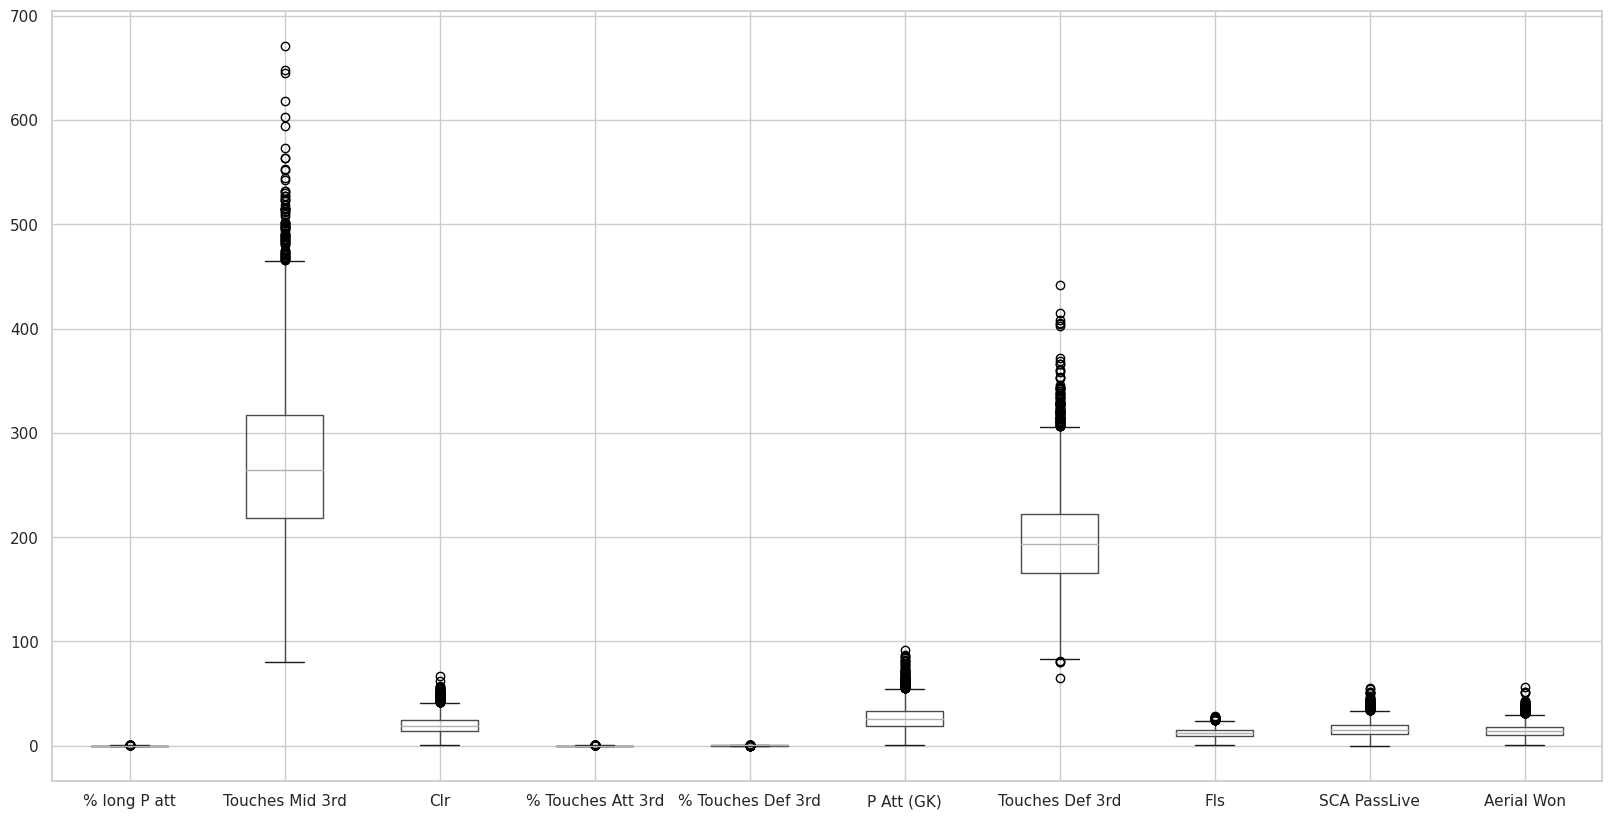

Methods to find the optimum number of clusters
Within Cluster Sum of Squares (WCSS) Method
Davies-Bouldin Index (DBI) Method
K-means clustering result:
Davies-Bouldin Index: 1.7206714721013687
[0 0 3 ... 2 0 1]
40168.364217545575
explained variance: [0.36370998 0.20626368 0.10867058]
total explained variance: 0.6786442380153705
Davies-Bouldin Index: 1.1703354230897705
Cluster centroids of PCA


calculation of the result in each cluster for italian league


    0
0   0
1  30
2  21
3  25
    0
0   1
1  36
2  49
3  52
    0
0   2
1  38
2  20
3  43
    0
0   3
1  64
2  24
3  48
calculation of the percentage of result in each cluster for italian league


          0
0  0.000000
1  0.394737
2  0.276316
3  0.328947
          0
0  1.000000
1  0.262774
2  0.357664
3  0.379562
          0
0  2.000000
1  0.376238
2  0.198020
3  0.425743
          0
0  3.000000
1  0.470588
2  0.176471
3  0.352941
Epsilon 1 clusters identified: 28 outliers identified: 5690
Epsilon 2 clusters identified: 1 outliers identified: 100
Epsilon 3 clusters identified: 1 outliers identified: 4
Epsilon 4 clusters identified: 1 outliers identified: 1
Epsilon 5 clusters identified: 1 outliers identified: 0
Epsilon 6 clusters identified: 1 outliers identified: 0
Epsilon 7 clusters identified: 1 outliers identified: 0
Epsilon 8 clusters identified: 1 outliers identified: 0
Epsilon 9 clusters identified: 1 outliers iden

Davies-Bouldin Index: 1.2223684586010903


Computing t-SNE embedding
Davies-Bouldin Index: 1.365643484827682


,0,1,2
0,0.543439,-0.624969,0.226781
1,-0.701342,0.482280,-0.027988
2,0.713268,-0.143728,0.144324
3,-0.759874,-0.347502,0.225018
4,0.948075,0.145869,-0.003134
5,0.206502,0.623350,0.401848
6,0.578432,0.702049,0.107828
7,0.107902,-0.489214,-0.351977
8,-0.687225,0.115226,0.331944
9,0.065566,-0.378201,0.745658


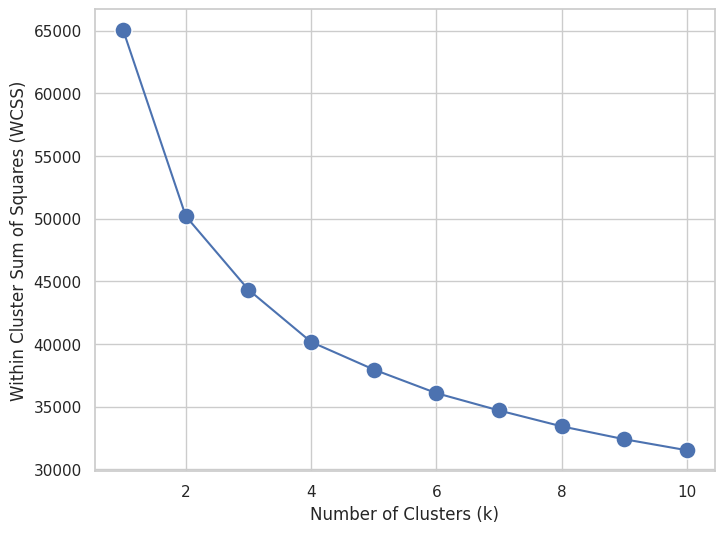

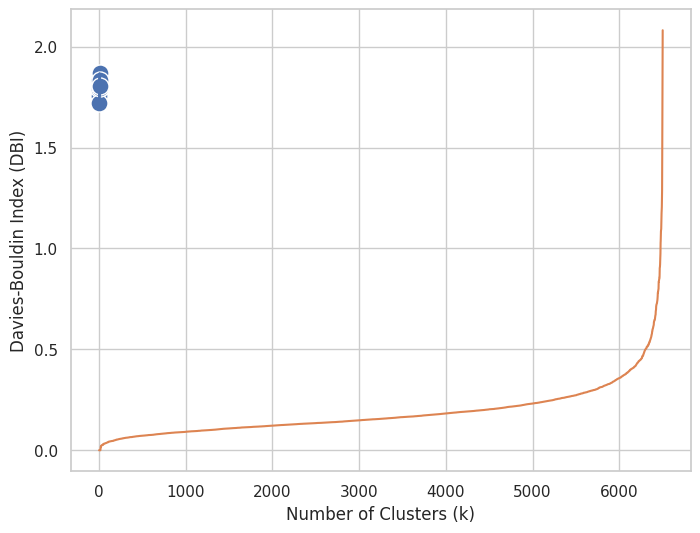

In [6]:
#Import of the different Tools used for the project
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from sklearn import metrics

# load the dataset
df = pd.read_csv('datawrd.csv',sep=';',encoding='iso-8859-1')

#storing of the categorical feature in a dataframe named 'y' and removing
#of the categoricla feature from the dataframe df
y = df[['Team','Date','Opp','Comp','Result','Ext/Home','Brut Result']]
df=df.drop(columns=['Team','Date','Opp','Comp','Result','Ext/Home',
                    'Brut Result'])

#selection of the features and creztion of a new datarame named F7
F7=df[['% long P att','Touches Mid 3rd','Clr','% Touches Att 3rd',
       '% Touches Def 3rd','P Att (GK)','Touches Def 3rd','Fls','SCA PassLive',
       'Aerial Won']]


#--------------------------------Data description------------------------------




#description analytics of the features selected in dataframe F7
F7.describe().T

# Set the style of the visualization
sns.set(style="whitegrid")
# Define the number of subplots along the grid row
n_cols = 4
# Define the number of subplots along the grid column
n_rows = int(len(F7.columns) / (n_cols-1))
# Initialize the subplot grid
fig, axs = plt.subplots(n_rows, n_cols, figsize=(25, 25))
# Flatten the axes
axs = axs.flatten()
# Iterate over each column and plot the distribution
for i, col in enumerate(F7.columns):
    sns.histplot(df[col], kde=False, ax=axs[i], bins=20)
    axs[i].set_title(f'Distribution of {col}')
    axs[i].set_ylabel('Frequency')
# Adjust the layout
plt.tight_layout()
# Display the plots
print("Histogram:")
plt.show()

# Correlation matrix heatmap
plt.figure(figsize=(20,14))
correlations = F7.corr()
print("Correlation Heatmap:")
sns.heatmap(round(correlations,2), cmap='RdBu',annot=True,
            annot_kws={"size": 10}, vmin=-1, vmax=1);
print("Boxplot:")
#Display of the boxplot for all the features
plt.figure(figsize=(20, 10))
F7.boxplot()
plt.show()


#----------------------------------K-mean modelling----------------------------


# Normalizing numerical features so that each feature has mean 0 and variance 1
scaler = StandardScaler()
X_scaled =scaler.fit_transform(F7)

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

#choose the right number of clusters
#WCSS
wcss = []
for k in range (1, 11):
    km=KMeans(n_clusters=k,n_init=25,random_state=1234)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
wcss_series=pd.Series(wcss, index= range(1,11))
plt.figure(figsize=(8,6))
print("Methods to find the optimum number of clusters")
print("Within Cluster Sum of Squares (WCSS) Method")
ax=sns.lineplot(y=wcss_series, x=wcss_series.index)
ax=sns.scatterplot(y=wcss_series, x=wcss_series.index, s=150)
ax=ax.set(xlabel='Number of Clusters (k)',
          ylabel='Within Cluster Sum of Squares (WCSS)')

DBI= []
for n in range(2,10):
 km= KMeans(n_clusters= n, n_init=25, random_state=1234)
 #array of cluster number per items
 km.fit(X_scaled)
 labels=km.labels_
 DBI.append(davies_bouldin_score(X_scaled, labels))
DBI_series=pd.Series(DBI, index= range(2,10))
plt.figure(figsize=(8,6))
print("Davies-Bouldin Index (DBI) Method")
ax=sns.lineplot(y=DBI_series, x=DBI_series.index)
ax=sns.scatterplot(y=DBI_series, x=DBI_series.index, s=150)
ax=ax.set(xlabel='Number of Clusters (k)',
          ylabel='Davies-Bouldin Index (DBI)')

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score


km= KMeans(n_clusters= 4, n_init=25, random_state=1234)
#array of cluster number per items
km.fit(X_scaled)
labels=km.labels_
WCSS=km.inertia_
centroids = pd.DataFrame(km.cluster_centers_)
centroids = centroids.rename(columns={0:'% long P att',1:'Touches Mid 3rd',
                                  2:'Clr',
                                  3:'% Touches Att 3rd',
                                  4:'% Touches Def 3rd',
                                  5:'P Att (GK)',
                                  6:'Touches Def 3rd',
                                  7:'Fls',
                                  8:'SCA PassLive',
                                  9:'Aerial Won'
                                  })

davies_bouldin_score(X_scaled, labels)
print("K-means clustering result:")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, labels)}")
print(labels)
print(WCSS)
centroids

#------------------------------Principal component analysis--------------------


#calculation of the covariance
cov = (X_scaled.T @ X_scaled) / (X_scaled.shape[0] - 1)

#calculation of 2 metrics from the covariance: eigenvalues and eigenvectors
#eigendecomposition function
eig_values, eig_vectors = np.linalg.eig(cov)
idx = np.argsort(eig_values, axis=0)[::-1]
sorted_eig_vectors = eig_vectors[:, idx]

# Applying PCA on X_scaled, the normalize data

#import of the PCA
from sklearn.decomposition import PCA
#initialisation of the loop n=1
#to 10 components

pca = PCA(n_components= 3)

X_pca = pca.fit_transform(X_scaled)


explained_variance = pca.explained_variance_ratio_
total_explained_variance_ratio=explained_variance.sum()

#print the number of comonents and the total variance
print("explained variance:",explained_variance)
print("total explained variance:",total_explained_variance_ratio)

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
#k-means algorithm apply to the principal components
km= KMeans(n_clusters= 4, n_init=25, random_state=1234)
#array of cluster number per items

km.fit(X_pca)
labels=km.labels_
km.inertia_
DBI=davies_bouldin_score(X_pca, labels)
print("Davies-Bouldin Index:",DBI)

centroids = km.cluster_centers_


centroids=pd.DataFrame(centroids)
print("Cluster centroids of PCA")
centroids

#list of the featue
features5=['% long P att','Touches Mid 3rd','Clr','% Touches Att 3rd',
           '% Touches Def 3rd','P Att (GK)','Touches Def 3rd','Fls',
           'SCA PassLive','Aerial Won']


import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_pca=pd.DataFrame(X_pca)
y=pd.DataFrame(y)
F=pd.concat([y,X_pca],axis=1)
F.rename(columns={0: 'PC1', 1: 'PC2',2:'PC3'}, inplace=True)
labels=pd.DataFrame(labels)
F=pd.concat([F,labels],axis=1)
F.rename(columns={0:'Clusters'}, inplace=True)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'],
                           index=features5)

l=["Bologna","Monza","Frosinone","Lazio","Milan","Roma"]

# Plot the 3D scatter plot for game won played by list of team in l
for i in range(len(l)):
  s1=F.loc[(F['Opp']==l[i]) & (F['Brut Result']=='W')]
  fig = px.scatter_3d(s1, x='PC1', y='PC2', z='PC3', color=s1['Clusters'],
                      text=s1['Team'],hover_data=['Date','Result','Ext/Home'],
                      title=l[i])
# Add annotations for loadings
  for feature in features5:
      fig.add_trace(go.Scatter3d(
          x=[0, loadings_df.loc[feature, 'PC1']],
          y=[0, loadings_df.loc[feature, 'PC2']],
          z=[0, loadings_df.loc[feature, 'PC3']],
          mode='lines+text',
          marker_color="red",
          text=['',feature],  # Empty text for the origin point
          showlegend=False,
      ))

  fig.show()

import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_pca=pd.DataFrame(X_pca)
y=pd.DataFrame(y)
F=pd.concat([y,X_pca],axis=1)
F.rename(columns={0: 'PC1', 1: 'PC2',2:'PC3'}, inplace=True)
labels=pd.DataFrame(labels)
F=pd.concat([F,labels],axis=1)
F.rename(columns={0:'Clusters'}, inplace=True)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'],
                           index=features5)

l=["Bologna","Monza","Frosinone","Lazio","Milan","Roma"]

# Plot the 3D scatter plot for game lost played by list of team in l
for i in range(len(l)):
  s1=F.loc[(F['Opp']==l[i]) & (F['Brut Result']=='L')]
  fig = px.scatter_3d(s1, x='PC1', y='PC2', z='PC3', color=s1['Clusters'],
                      text=s1['Team'],hover_data=['Date','Result','Ext/Home'],
                      title=l[i])
# Add annotations for loadings
  for feature in features5:
      fig.add_trace(go.Scatter3d(
          x=[0, loadings_df.loc[feature, 'PC1']],
          y=[0, loadings_df.loc[feature, 'PC2']],
          z=[0, loadings_df.loc[feature, 'PC3']],
          mode='lines+text',
          marker_color="red",
          text=['',feature],  # Empty text for the origin point
          showlegend=False,
      ))

  fig.show()


centroids=pd.DataFrame(centroids)
centroids
loadings=pd.DataFrame(loadings)
loadings


#use of concat function to add the categorical value and cluster label
#to the dataset
A=pd.concat([y,df,labels],axis=1)

A=A.rename(columns={0:"Clusters"})


#count of the team in competition it Serie A and cluster 3
A=A.loc[(A["Comp"]=="it Serie A") & (A["Clusters"]==3)]
counts = A['Team'].value_counts()
counts=pd.DataFrame(counts)
counts

labels=pd.DataFrame(labels)
A=pd.concat([y,df,labels],axis=1)

A=A.rename(columns={0:"Clusters"})


#calculation of the result in each cluster for italian league
print("calculation of the result in each cluster for italian league")
print("\n")
for i in range(4):
  A=A.loc[(A['Comp']=="it Serie A")]
  D=pd.DataFrame([i,len(A[(A['Clusters']==i) & (A['Brut Result']=="W")]),

                  len(A[(A['Clusters']==i) & (A['Brut Result']=="D")]),

                  len(A[(A['Clusters']==i) & (A['Brut Result']=="L")])])


  print(D)



#calculation of the percentage of result in each cluster for italian league
print("calculation of the percentage of result in each cluster for italian \
league")
print("\n")
for i in range(4):
  A=A.loc[(A['Comp']=="it Serie A")]
  D=pd.DataFrame([i,len(A[(A['Clusters']==i) & (A['Brut Result']=="W")])/
                  len(A[(A['Clusters']==i)]),

                  len(A[(A['Clusters']==i) & (A['Brut Result']=="D")])/
                  len(A[(A['Clusters']==i)]),

                  len(A[(A['Clusters']==i) & (A['Brut Result']=="L")])/
                  len(A[(A['Clusters']==i)])])

  print(D)


#-------------------------PCA + DBSCAN Modelling-------------------------------------

from sklearn.cluster import DBSCAN
from sklearn import metrics
#import of the NearestNeighbors module
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

for n in range(1,10):
 clustering = DBSCAN(eps=n, min_samples=6).fit(X_scaled)
 core_samples_mask = np.zeros_like(clustering.labels_, dtype=bool)
 core_samples_mask[clustering.core_sample_indices_] = True
 labels = clustering.labels_
# Number of clusters in labels, ignoring noise if present.
 n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
 n_noise_ = list(labels).count(-1)
 print("Epsilon",n,"clusters identified:",n_clusters_ ,
       "outliers identified:",n_noise_)
 clustering = DBSCAN(eps=0.5, min_samples=6).fit(X_pca)
core_samples_mask = np.zeros_like(clustering.labels_, dtype=bool)
core_samples_mask[clustering.core_sample_indices_] = True
labels = clustering.labels_
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("clusters identified:",n_clusters_ ,"     outliers identified:",n_noise_)
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_pca=pd.DataFrame(X_pca)
y=pd.DataFrame(y)
F=pd.concat([y,X_pca],axis=1)
F.rename(columns={0: 'PC1', 1: 'PC2',2:'PC3'}, inplace=True)
labels=pd.DataFrame(labels)
F=pd.concat([F,labels],axis=1)
F.rename(columns={0:'Clusters'}, inplace=True)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'],
                           index=features5)
s1=F
# Plot the 3D scatter plot
fig = px.scatter_3d(s1, x='PC1', y='PC2', z='PC3', color=s1['Clusters'],
                    hover_data=['Team','Date','Result','Ext/Home','Opp'])
for feature in features5:
    fig.add_trace(go.Scatter3d(
        x=[0, loadings_df.loc[feature, 'PC1']],
        y=[0, loadings_df.loc[feature, 'PC2']],
        z=[0, loadings_df.loc[feature, 'PC3']],
        mode='lines+text',
        marker_color="red",
        text=['',feature],  # Empty text for the origin point
        showlegend=False,
    ))

fig.show()
centroids=pd.DataFrame(centroids)
centroids
loadings=pd.DataFrame(loadings)
loadings


 #---------------------------------PCA + GMM-----------------------------------------


from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_pca)
# Get the cluster labels
labels = gmm.predict(X_pca)
# Calculate Davies-Bouldin Index
db_index = davies_bouldin_score(X_pca, labels)
print(f"Davies-Bouldin Index: {db_index}")

import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_pca=pd.DataFrame(X_pca)
y=pd.DataFrame(y)
F=pd.concat([y,X_pca],axis=1)
F.rename(columns={0: 'PC1', 1: 'PC2',2:'PC3'}, inplace=True)
labels=pd.DataFrame(labels)
F=pd.concat([F,labels],axis=1)
F.rename(columns={0:'Clusters'}, inplace=True)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'],
                           index=features5)

s1=F.loc[(F['Team']=='Milan')]


# Plot the 3D scatter plot
fig = px.scatter_3d(s1, x='PC1', y='PC2', z='PC3', color=s1['Clusters'],
                    hover_data=['Team','Date','Result','Ext/Home','Opp'],
                    text=s1['Opp'])
# Add annotations for loadings
for feature in features5:
    fig.add_trace(go.Scatter3d(
        x=[0, loadings_df.loc[feature, 'PC1']],
        y=[0, loadings_df.loc[feature, 'PC2']],
        z=[0, loadings_df.loc[feature, 'PC3']],
        mode='lines+text',
        marker_color="red",
        text=['',feature],  # Empty text for the origin point
        showlegend=False,
    ))

fig.show()

centroids = km.cluster_centers_

centroids=pd.DataFrame(centroids)
centroids
loadings=pd.DataFrame(loadings)
loadings

#-------------------------------t-SNE + K-means---------------------------------
## Computing t-SNE
from time import time
from sklearn import (manifold, datasets, decomposition, ensemble,
             discriminant_analysis, random_projection)
print("Computing t-SNE embedding")
tsne = manifold.TSNE(n_components=3, init='pca', random_state=0)
t0 = time()
X_tsne = tsne.fit_transform(X_scaled)

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

km= KMeans(n_clusters= 4, n_init=25, random_state=1234)
#array of cluster number per items

km.fit(X_tsne)
labels=km.labels_
km.inertia_
DBI=davies_bouldin_score(X_pca, labels)
print("Davies-Bouldin Index:",DBI)

import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_tsne=pd.DataFrame(X_tsne)
y=pd.DataFrame(y)
F=pd.concat([y,X_tsne],axis=1)
F.rename(columns={0: 'PC1', 1: 'PC2',2:'PC3'}, inplace=True)
labels=pd.DataFrame(labels)
F=pd.concat([F,labels],axis=1)
F.rename(columns={0:'Clusters'}, inplace=True)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'],
                           index=features5)

s1=F.loc[(F['Team']=='Las Palmas')]


# Plot the 3D scatter plot
fig = px.scatter_3d(s1, x='PC1', y='PC2', z='PC3',
                    color=s1['Clusters'],hover_data=['Team','Date','Result',
                                                     'Ext/Home','Opp'],
                    text=s1['Opp'])
# Add annotations for loadings
for feature in features5:
    fig.add_trace(go.Scatter3d(
        x=[0, loadings_df.loc[feature, 'PC1']],
        y=[0, loadings_df.loc[feature, 'PC2']],
        z=[0, loadings_df.loc[feature, 'PC3']],
        mode='lines+text',
        marker_color="red",
        text=['',feature],  # Empty text for the origin point
        showlegend=False,
    ))

fig.show()
centroids=pd.DataFrame(centroids)
centroids
loadings=pd.DataFrame(loadings)
loadings
